In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import box
from matplotlib.dates import DateFormatter
import netCDF4 as nc
import glob
import cartopy.feature as cfeature


In [2]:
# use my matplotlib params
import my_params 
import matplotlib as mpl
%config InlineBackend.figure_format = 'svg' 
custom_params = my_params.params()
mpl.rcParams.update(custom_params)


In [3]:
df = pd.read_csv("sc_ExampleSat-1_logs.csv")
df.describe()

,Latitude,Longitude,Altitude_km,Solar_Current_A
count,1000.000000,1000.000000,980.000000,1000.000000
mean,1.234231,0.505380,504.655276,2.516700
std,34.936306,103.381701,14.190780,3.651482
min,-51.593300,-179.827700,485.010000,0.000000
25%,-31.805600,-87.810775,490.200000,0.000000
50%,2.452800,1.927500,504.730000,0.000000
75%,34.942300,88.679375,518.650000,5.370000
max,51.593300,179.498500,525.000000,10.370000


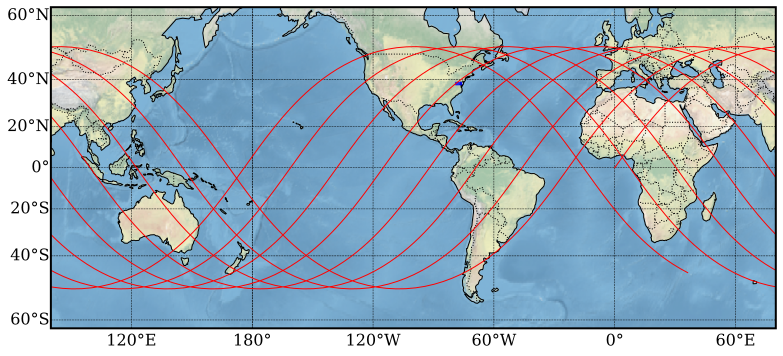

In [7]:
fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=ccrs.Mercator(central_longitude=-100))


ax.set_global()
ax.stock_img() 
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(linewidth=0.5, linestyle="--", color= 'k', draw_labels=True, zorder = 0)
gl.top_labels = False
gl.right_labels = False

#ax.gridlines(linewidth=0.5, linestyle="--", color= 'k')

ax.plot(df['Longitude'], df['Latitude'], transform=ccrs.Geodetic(), linewidth=1, color = 'red')


lat_min, lat_max = (38, 39) #North
lon_min, lon_max = (-79, -76) #West

# Calculate box corners
extent = [lon_min, lon_max, lat_min, lat_max]

dc_box = box(extent[0], extent[2], extent[1], extent[3])
ax.add_geometries([dc_box], crs=ccrs.PlateCarree(), 
                  facecolor='blue', edgecolor='blue', alpha=0.8)

ax.set_extent([-180, 180, -62, 62], crs=ccrs.PlateCarree())

fig.savefig('plots/ground_path_whole.png', dpi = 200, bbox_inches='tight')

In [9]:
# Index Dataframe where satellite is over restricted area
mask_long = np.logical_and( df['Longitude'] > -79, df['Longitude'] < -76)
mask_lat = np.logical_and( df['Latitude'] > 38, df['Latitude'] < 39)

comb_mask = np.logical_and(mask_long, mask_lat)

df_anomaly = df[comb_mask]

print(df_anomaly)

               Timestamp          selectID    Spacecraft  Latitude  Longitude  \
592  2024-01-15 20:05:26  3daspwfskqafp24u  ExampleSat-1   38.8785   -78.6791   

     Altitude_km  Solar_Current_A Battery_Voltage_V  
592       516.98             6.43              33.0  


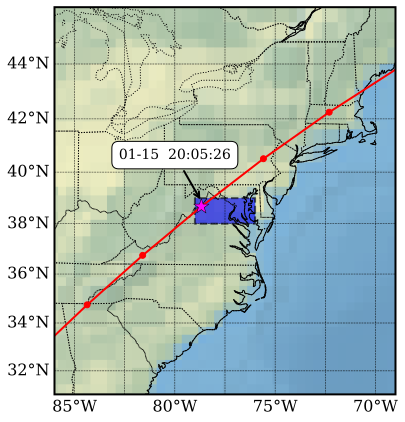

In [10]:
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.Mercator(central_longitude=-100))

ax.set_global()
ax.stock_img()  # Add basic map background
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

gl = ax.gridlines(linewidth=0.5, linestyle="--", color= 'k', draw_labels=True, zorder = 0)
gl.top_labels = False
gl.right_labels = False

ax.plot(df['Longitude'], df['Latitude'], transform=ccrs.Geodetic(), linewidth=2, color = 'red', zorder = 2)
ax.scatter(df['Longitude'], df['Latitude'], transform=ccrs.Geodetic(), linewidth=1, marker = '.', color = 'red', zorder = 2, s = 12**2)


ax.scatter(df_anomaly['Longitude'], df_anomaly['Latitude'], transform=ccrs.Geodetic(), linewidth=0.5, marker = '*', color = 'fuchsia', zorder = 2, s = 16**2, edgecolor = 'k')
lat_min, lat_max = (38, 39) #North
lon_min, lon_max = (-79, -76) #West

# Calculate box corners
extent = [lon_min, lon_max, lat_min, lat_max]

dc_box = box(extent[0], extent[2], extent[1], extent[3])
ax.add_geometries([dc_box], crs=ccrs.PlateCarree(), 
                  facecolor='blue', edgecolor='black', lw = 2, ls = '--',alpha=0.6, zorder = 1)

ax.set_extent([lon_min -7, lon_max + 7, lat_min - 7, lat_max + 7], crs=ccrs.PlateCarree())


ax.annotate(r'01-15  20:05:26', 
            xy=( df_anomaly['Longitude'].values[0], df_anomaly['Latitude'].values[0]),
            xytext=(-80.0, 40.5),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            #xycoords='axes fraction', 
            ha='center',
            fontsize = 14,
            arrowprops=dict(arrowstyle='->', facecolor='w', edgecolor='k', lw = 2),
           bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
ax.set_aspect('equal')

fig.savefig('plots/ground_path_zoom.png', dpi = 200,bbox_inches='tight')
#ax.set_xlabel('Longitude')

              Timestamp          selectID    Spacecraft  Latitude  Longitude  \
800 2024-01-15 22:51:50  o0jxbjydyikaztb5  ExampleSat-1  -12.2066  -169.8727   

     Altitude_km  Solar_Current_A  Battery_Voltage_V  
800       524.26             9.36              112.0  


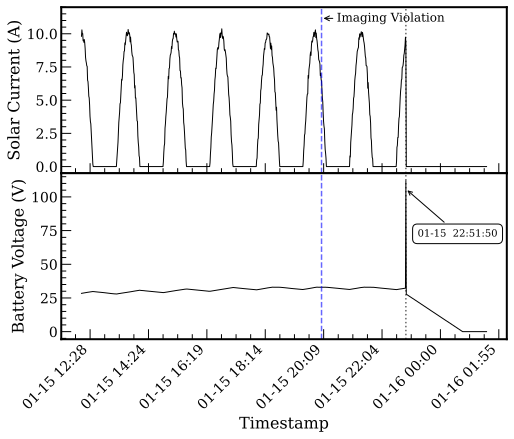

In [12]:
# Plot the Battery Voltage

# First, we need to deal with read errors. 
# We will set read erors to np.nan
df = pd.read_csv("sc_ExampleSat-1_logs.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df.loc[df['Battery_Voltage_V'] == 'ERR_READ', 'Battery_Voltage_V'] = np.nan

# Convert from object/string dtype to float
df['Battery_Voltage_V'] = pd.to_numeric(df['Battery_Voltage_V'], errors='coerce')

fig, ax = plt.subplots( nrows = 2, ncols = 1, figsize=(8, 6), sharex = True)

ax[1].set_xlabel('Timestamp')
ax[0].set_ylabel('Solar Current (A)')
ax[1].set_ylabel('Battery Voltage (V)')

ax[0].plot(df['Timestamp'], df['Solar_Current_A'], lw=1, c='k')
ax[1].plot(df['Timestamp'], df['Battery_Voltage_V'], lw=1, c='k')


# Draw a vertical line where the satellite was over the restricted area
ax[1].axvline(x = df_anomaly['Timestamp'], ymin = 0, ymax = 100, c = 'b', ls = '--', alpha= 0.6)
ax[0].axvline(x = df_anomaly['Timestamp'], ymin = 0, ymax = 100, c = 'b', ls = '--', alpha= 0.6)

plt.xticks(rotation=45, ha='right')
ax[1].xaxis.set_major_locator(plt.MaxNLocator(10))
ax[1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
plt.subplots_adjust(wspace=0, hspace=0)
#plt.tight_layout()
ax[0].set_ylim([-0.5, 12])
ax[0].annotate('Imaging Violation', 
               xy=(pd.Timestamp(df_anomaly['Timestamp'].values[0]), ax[0].get_ylim()[1]* 0.93),
               xytext=(pd.Timestamp(df_anomaly['Timestamp'].values[0]) + pd.Timedelta(hours=0.5), 
                       ax[0].get_ylim()[1] * 0.93),
               fontsize=12, color='k', va='center',
               arrowprops=dict(arrowstyle='->', color='k'))

# Find the timestamp where the battery voltage spiked
volt_anomaly = df[ df['Battery_Voltage_V'] > 100]
print(volt_anomaly)


ax[1].annotate(r'01-15  22:51:50',
            xy=( pd.Timestamp(volt_anomaly['Timestamp'].values[0]), ax[1].get_ylim()[1]* 0.9),
            xytext=(pd.Timestamp(volt_anomaly['Timestamp'].values[0]) + pd.Timedelta(hours=1.7), ax[1].get_ylim()[1] * 0.6),
            ha='center',
            fontsize = 10,
            arrowprops=dict(arrowstyle='->', color='k', lw = 1),
           bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
              )

ax[1].axvline(x = volt_anomaly['Timestamp'], ymin = 0, ymax = 100, c = 'k', ls = ':', alpha= 0.6)
ax[0].axvline(x = volt_anomaly['Timestamp'], ymin = 0, ymax = 12, c = 'k', ls = ':', alpha= 0.6)
plt.show()


fig.savefig('plots/battery_current.png', dpi = 200,bbox_inches='tight')

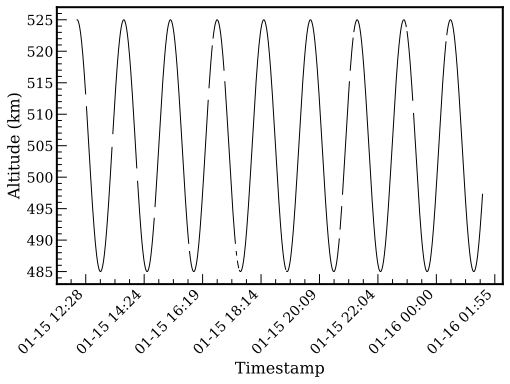

In [14]:
# Look at the altitude
fig, ax = plt.subplots( figsize = (8,5))
ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Timestamp')

ax.plot(df['Timestamp'], df['Altitude_km'], lw=1, c='k')

plt.xticks(rotation=45, ha='right')
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))

In [16]:
# need to load in the electron flux and proton flux data
# Took this data from: https://www.ncei.noaa.gov/products/poes-metop-space-environment-monitor
# "Processed level 1b data"; 2024 -> metop03
# 7 day interval around the anomaly

files = sorted(glob.glob('noaa_data/poes_m03_202401*_proc.nc'))

cols = [
    'time',
    'mep_pro_tel0_flux_p3', 'mep_pro_tel90_flux_p3',
    'mep_pro_tel0_flux_p4', 'mep_pro_tel90_flux_p4',
    'mep_ele_tel0_flux_e1', 'mep_ele_tel90_flux_e1',
    'mep_ele_tel0_flux_e2', 'mep_ele_tel90_flux_e2',
    'mep_ele_tel0_flux_e3', 'mep_ele_tel90_flux_e3'
]

dfs = []
for f in files:
    ds = nc.Dataset(f)
    data = {}
    for var in cols:
        raw = ds.variables[var][:].data  # .data gets the raw numpy array, ignoring the mask
        data[var] = raw
    ds.close()
    dfs.append(pd.DataFrame(data))

combined_df = pd.concat(dfs, ignore_index=True)
combined_df['timestamp'] = pd.to_datetime(combined_df['time'], unit='ms', errors='coerce')

# Get hourly averages
hourly_df = combined_df.set_index('timestamp').resample('h').mean(numeric_only=True)

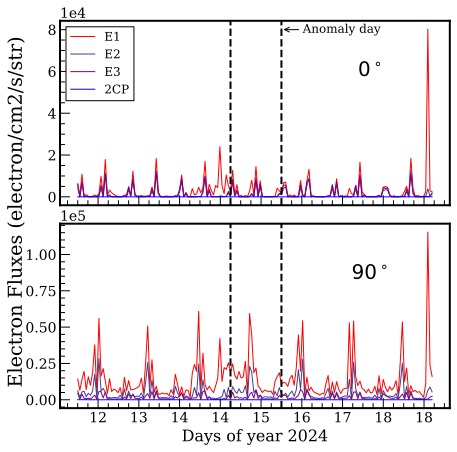

In [18]:


fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(7, 7), sharex = True)
fig.supylabel('Electron Fluxes (electron/cm2/s/str)')
ax[1].set_xlabel('Days of year 2024')
ax[0].plot(hourly_df.index, hourly_df['mep_ele_tel0_flux_e1'], lw=1, c='r', label = 'E1')
ax[0].plot(hourly_df.index, hourly_df['mep_ele_tel0_flux_e2'], lw=1, c='darkslateblue', label = 'E2')
ax[0].plot(hourly_df.index, hourly_df['mep_ele_tel0_flux_e3'], lw=1, c='purple', label = 'E3')
ax[0].plot(hourly_df.index, 2*(hourly_df['mep_pro_tel0_flux_p3'] + hourly_df['mep_pro_tel0_flux_p4']), lw=1, c='blue', label = '2CP')

ax[1].plot(hourly_df.index, hourly_df['mep_ele_tel90_flux_e1'], lw=1, c='r', label = 'E1')
ax[1].plot(hourly_df.index, hourly_df['mep_ele_tel90_flux_e2'], lw=1, c='darkslateblue', label = 'E2')
ax[1].plot(hourly_df.index, hourly_df['mep_ele_tel90_flux_e3'], lw=1, c='purple', label = 'E3')
ax[1].plot(hourly_df.index, 2*(hourly_df['mep_pro_tel90_flux_p3'] + hourly_df['mep_pro_tel90_flux_p4']), lw=1, c='blue', label = '2CP')

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].xaxis.set_major_locator(plt.MaxNLocator(10))
ax[0].xaxis.set_major_formatter(DateFormatter('%d'))
ax[0].legend(fontsize = 12,frameon = True, fancybox = False, framealpha = 1, edgecolor = 'k')

ax[0].annotate(r'$0^\circ$', xy=(0.8, 0.7),xycoords='axes fraction', ha='center',fontsize = 20)
ax[1].annotate(r'$90^\circ$', xy=(0.8, 0.7),xycoords='axes fraction', ha='center',fontsize = 20)

#ax[1].axvline(x = df_anomaly['Timestamp'])#, ymin = 0, ymax = 100)



ax[1].axvline(x=pd.Timestamp('2024-01-15 00:00:00'), ls='--', c='k', lw=2)
ax[1].axvline(x=pd.Timestamp('2024-01-16 00:00:00'), ls='--', c='k', lw=2)


ax[0].axvline(x=pd.Timestamp('2024-01-15 00:00:00'), ls='--', c='k', lw=2)
ax[0].axvline(x=pd.Timestamp('2024-01-16 00:00:00'), ls='--', c='k', lw=2)

ax[0].annotate('Anomaly day', 
               xy=(pd.Timestamp('2024-01-16 00:00:00'), ax[0].get_ylim()[1]* 0.95),
               xytext=(pd.Timestamp('2024-01-16 10:00:00'), ax[0].get_ylim()[1] * 0.95),
               arrowprops=dict(arrowstyle='->', color='k'),
               fontsize=12, color='k', va = 'center')

plt.subplots_adjust(wspace=0, hspace=0.1)
#plt.tight_layout()


fig.savefig('plots/elec_fluxes.png', dpi = 200,bbox_inches='tight')
plt.show()

In [19]:
# Calculate corrected electron flux

CP_0 = hourly_df['mep_pro_tel0_flux_p3'] + hourly_df['mep_pro_tel0_flux_p4']
CP_90 = hourly_df['mep_pro_tel90_flux_p3'] + hourly_df['mep_pro_tel90_flux_p4']

E1_0_corr = hourly_df['mep_ele_tel0_flux_e1'] - CP_0
E1_90_corr = hourly_df['mep_ele_tel90_flux_e1'] - CP_90

E1_corr = np.hypot( E1_0_corr, E1_90_corr)

# Load magnetic data
mag_df = pd.read_csv('noaa_data/geomagnetic_data.csv', sep=',')
mag_df['month'] = np.ones(len(mag_df))
mag_df['timestamp'] = pd.to_datetime(mag_df[['year', 'month', 'day', 'hour']])
print(mag_df.columns)


Index(['year', 'day', 'hour', 'kp_index', 'dst_indexc', 'f10.7_index', 'month',
       'timestamp'],
      dtype='str')


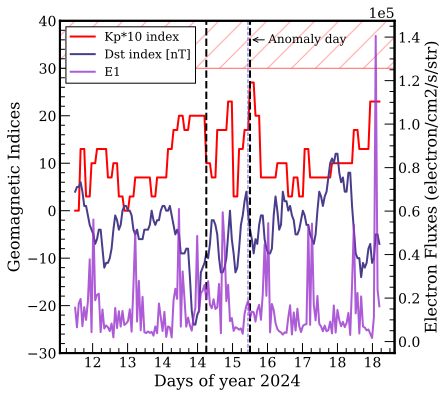

In [20]:
# Recreate figure 4 in https://link.springer.com/article/10.1186/s40623-018-0852-2

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(6, 6) )
ax.set_ylabel('Geomagnetic Indices')
#ax.set_ylabel('Electron Fluxes (electron/cm2/s/str)')
ax.set_xlabel('Days of year 2024')

ax.plot(mag_df['timestamp'], mag_df['kp_index'], lw=2, c='r',  label = 'Kp*10 index')
ax.plot(mag_df['timestamp'], mag_df['dst_indexc'], lw=2, c='darkslateblue',  label = 'Dst index [nT]')

#ax.legend(fontsize = 12, frameon = True)
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
ax.xaxis.set_major_formatter(DateFormatter('%d'))

ax.axvline(x=pd.Timestamp('2024-01-15 00:00:00'), ls='--', c='k', lw=2)
ax.axvline(x=pd.Timestamp('2024-01-16 00:00:00'), ls='--', c='k', lw=2)

ax.axvline(x=pd.Timestamp('2024-01-15 22:51:50'), ls='--', c='slateblue', lw=1)


ax.set_ylim([-30, 40])
ax.axhspan(30, 90, alpha=0.6, color='r', hatch='/', fill = False)

ax.annotate('Anomaly day', 
               xy=(pd.Timestamp('2024-01-16 00:00:00'), ax.get_ylim()[1]* 0.9),
               xytext=(pd.Timestamp('2024-01-16 10:00:00'), ax.get_ylim()[1] * 0.9),
               arrowprops=dict(arrowstyle='->', color='k'),
               fontsize=12, color='k', va = 'center')



ax2 = ax.twinx() 
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax2.plot(hourly_df.index, E1_corr, lw=2, c='darkorchid', label = 'E1', alpha = 0.8)



ax2.set_ylabel('Electron Fluxes (electron/cm2/s/str)')


h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize =12, frameon = True, fancybox = False, framealpha = 1, edgecolor = 'k')

fig.savefig('plots/geo_indices.png', dpi = 200,bbox_inches='tight')